# "Accrual quality" sorts good earnings from noisy ones. Can you trade it? 📊
### A textbook accounting-quality measure that *genuinely* flags flaky earnings — and that the stock market shrugs at

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Earnings persistence%3F: Confirmed](https://img.shields.io/badge/Earnings_persistence%3F-Confirmed-8b949e?style=flat-square)

Here's a signal with real accounting logic. Reported earnings are cash flow plus **accruals** — the bookkeeping that shifts timing (a credit sale is revenue now, cash later). Dechow & Dichev (2002) noticed that some firms' accruals map cleanly into the cash that follows, while others' are mostly guesswork that reverses later. Measure how *badly* a firm's accruals track its cash flow — the wobble left over after you line them up — and you've got **accrual quality**. High wobble = low-quality, noisy earnings. The pitch: low-quality earnings are discounted, so buy the clean-quality names and short the noisy ones.

Half of that is dead right. The other half — the part with the money in it — isn't.

> 📓 **Plain-language layer.** Want the Newey-West *t*-stats, the placebo and the cost math? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Method note.** 45 deep-history US non-financial names (42 clear the data bar) with clean EDGAR fundamentals, 2010→2026; a genuinely **thin, uneven panel** (the rolling window needs ~4 years before a first signal). House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from accrual_quality import data, strategy as st

HAVE_REAL = data.have_real()
if HAVE_REAL:
    PX, EV = data.load_real()
else:
    PX = EV = None
print("real cache present:", HAVE_REAL, "| events:", (0 if EV is None else len(EV)),
      "| names:", (0 if EV is None else EV['ticker'].nunique()))

# frozen headline numbers (mirror of docs/results.md)
R = {'as_of': '2026-06-30', 'n_names': 42, 'n_events': 2066, 'end_lo': '2010-10-31', 'end_hi': '2026-03-31', 'fp_prices': 'f0610f2cc06e', 'n_months': 182, 'avg_n': 33.5, 'ls_span_lo': '2011-05-31', 'ls_span_hi': '2026-06-30', 'ls_mean_bps': -3.6, 'ls_ann': -0.44, 'ls_t_iid': -0.19, 'ls_t_nw': -0.18, 'ls_sharpe': -0.05, 'ls_hit': 49, 'ls_long_bps': 124.3, 'ls_short_bps': 127.9, 'ls_turn': 0.07, 'ls_cum': 0.88, 'ls120_mean_bps': -6.7, 'ls120_t_nw': -0.33, 'wc_mean_bps': -10.7, 'wc_t_nw': -0.47, 'wc_sharpe': -0.11, 'xsec_early': 25.9, 'xsec_late': 39.7, 'drift': {21: (2066, 1.01, 1.25, -0.24, -0.58, 51, 0.7269), 63: (2038, 3.4, 3.96, -0.56, -0.79, 52, 0.7985), 126: (1999, 7.19, 8.17, -0.98, -0.91, 53, 0.8444)}, 'mono63': (3.96, 3.36, 3.4), 'era_early_n': 80, 'era_early_bps': 0.4, 'era_early_t': 0.02, 'era_late_n': 102, 'era_late_bps': -6.8, 'era_late_t': -0.23, 'p_n': 2066, 'good_slope': 0.87, 'good_t': 19.97, 'poor_slope': 0.273, 'poor_t': 8.59, 'slope_gap': 0.596, 'good_earn_vol': 0.53, 'poor_earn_vol': 2.44, 'net': {(10, 50): (-9.2, -1.1, -0.46, -0.12), (20, 100): (-14.7, -1.77, -0.73, -0.2)}, 'syn_null_mean': 0.1, 'syn_null_sd': 1.08, 'syn_null_fire': 1, 'syn_null_seeds': 12, 'syn_planted_bps': 982.0, 'syn_planted_t': 23.79}


real cache present: True | events: 2066 | names: 42


## The answer first

| Question | Answer |
|---|---|
| Does accrual quality flag real **earnings** differences? | **Yes — strongly.** The clean-quality names have earnings that **persist** (this quarter's profitability carries +0.87 into next quarter) and are ~**5× less volatile** than the noisy-quality names (+0.27 carry, 2.4% vs 0.5% swings). The measure works exactly as advertised. |
| Does it predict future **returns**? | **No.** A long-short that buys high-quality names and shorts low-quality ones earns **-0.4%/yr** — i.e. essentially zero, and if anything a hair the *wrong* way (robust *t* = **-0.18**, the bar is 2). |
| Why the gap? | "This firm has noisier earnings" is a slow, **public** fundamental. Anyone can compute it from the filings; the market has long since priced whatever discount noisy earnings deserve. A real fact about the *business* is not automatically a signal about the *stock*. |
| Can you trade it? | **No.** The spread doesn't clear the bar even before costs — there's nothing to charge costs against. |

> Real information about earnings quality. No alpha in the stock. That distinction is the whole study.

## 1 · The claim

> *"Earnings whose accruals don't line up with cash flows are low-quality — noisier, less reliable, and discounted. So buy the names whose accruals track cash cleanly, and short the ones whose accruals are all estimation noise."*

It's a specific case of a respectable academic idea — the market misprices the *accrual* pieces of earnings (Sloan 1996). Dechow-Dichev sharpen it from *how much* accrual there is to *how reliable* it is: regress accruals on the cash flows they're supposed to anticipate, and the **leftover wobble** is your quality score.

## 2 · So what?

If a number you can compute from three lines of every cash-flow statement predicted stock returns, it would be one of the easiest anomalies going — no estimates feed, no alt-data. That's exactly why it deserves suspicion: it's *too* readable. Everyone with the filings can measure accrual quality. If markets price public information at all, this is the kind they should price fastest.

## 3 · How would we even know?

- **The signal.** For each of 42 deep-history names, the **wobble** (residual standard deviation) left after regressing accruals on lagged / current / next-quarter operating cash flow, over a rolling 12-quarter window — known only on the **filing date** (never using a future cash-flow number that isn't public yet).
- **The earnings test.** Do the clean-quality names actually have steadier, more persistent earnings? (The accounting claim.)
- **The return test.** Each month, rank the names on quality, buy the top third, short the bottom third, hold for the next month. Does the spread make money — and can we tell it apart from noise?
- **The mirage check.** If the return spread can't beat a coin-flip relabelling of the names, it's not a signal, however good the story sounds.

## 4 · The teardown — let's actually look

**First, the part that works: does accrual quality really separate steady earners from noisy ones?** We split the names into best- and worst-quality thirds and ask how much of this quarter's profitability carries into next quarter (persistence), and how volatile their earnings are.

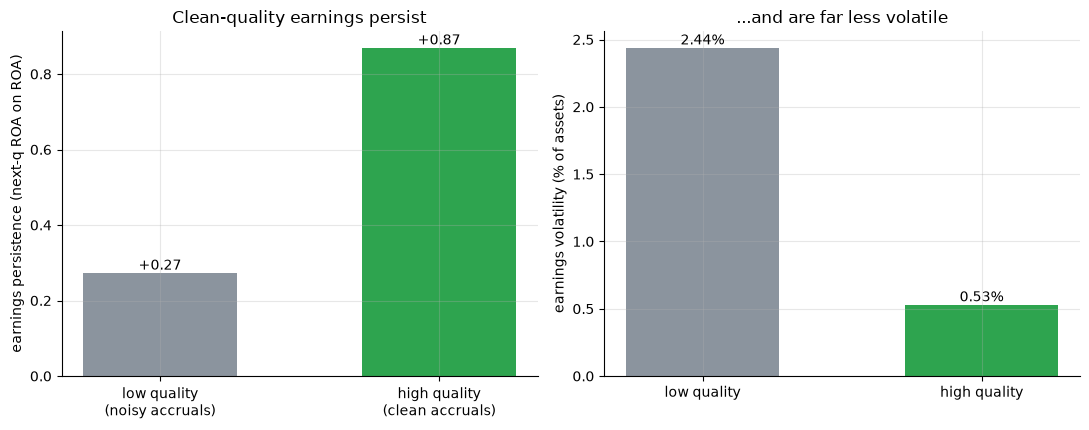

persistence: high-quality +0.87 vs low-quality +0.27  |  earnings vol: high-quality 0.53% vs low-quality 2.44% of assets


In [2]:
if HAVE_REAL:
    q = st.persistence_by_quality(EV)
    gs, ps = q['good_slope'], q['poor_slope']
    gev, pev = q['good_earn_vol']*100, q['poor_earn_vol']*100
else:
    gs, ps = R['good_slope'], R['poor_slope']
    gev, pev = R['good_earn_vol'], R['poor_earn_vol']
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11.0, 4.4))
a1.bar(['low quality\n(noisy accruals)','high quality\n(clean accruals)'], [ps, gs],
       color=[GREY, GREEN], width=.55)
for i,v in enumerate([ps, gs]): a1.annotate(f'{v:+.2f}',(i,v),ha='center',va='bottom')
a1.set_ylabel('earnings persistence (next-q ROA on ROA)'); a1.set_title('Clean-quality earnings persist')
a2.bar(['low quality','high quality'], [pev, gev], color=[GREY, GREEN], width=.55)
for i,v in enumerate([pev, gev]): a2.annotate(f'{v:.2f}%',(i,v),ha='center',va='bottom')
a2.set_ylabel('earnings volatility (% of assets)'); a2.set_title('...and are far less volatile')
plt.tight_layout(); plt.show()
print(f'persistence: high-quality {gs:+.2f} vs low-quality {ps:+.2f}  |  '
      f'earnings vol: high-quality {gev:.2f}% vs low-quality {pev:.2f}% of assets')

That's the accounting claim, **confirmed decisively**. High-quality earnings carry **+0.87** quarter-to-quarter versus only **+0.27** for low-quality names, and they swing about **5× less** (0.5% vs 2.4% of assets). The Dechow-Dichev measure is not folklore — it really does sort steady earners from flaky ones.

**So now the money question: do the stocks follow?** Same ranking, but instead of earnings we measure the forward *return* of a buy-the-high-quality, short-the-low-quality portfolio.

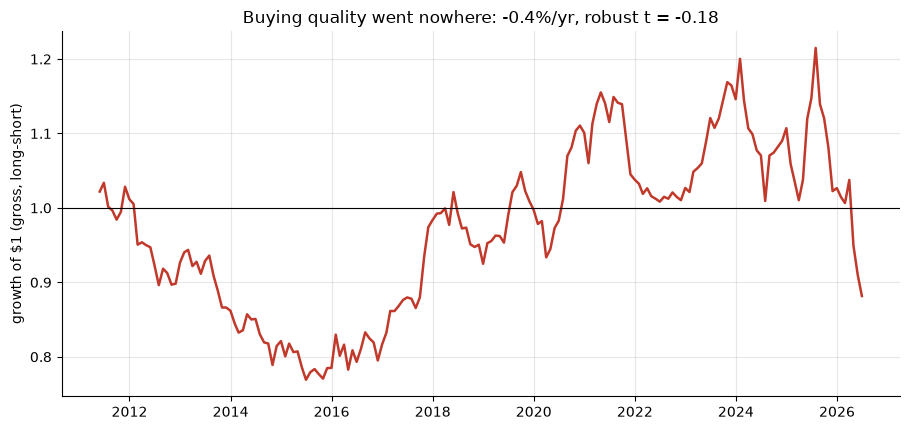

long-short: -0.4%/yr gross, Newey-West t = -0.18 (the bar is 2)


In [3]:
if HAVE_REAL:
    ls = st.calendar_ls(PX, EV, signal_col='quality', n_buckets=3, min_names=6, staleness_days=200)
    s = st.calendar_ls_stats(ls)
    ann, tnw = s['ann_pct'], s['t_nw']
    cum = (1+ls['ls']).cumprod()
else:
    ann, tnw = R['ls_ann'], R['ls_t_nw']
    cum = None
fig, ax = plt.subplots(figsize=(9.2, 4.4))
if cum is not None:
    ax.plot(cum.index, cum.values, color=RED, lw=1.8)
    ax.axhline(1.0, c='k', lw=.8)
    ax.set_ylabel('growth of $1 (gross, long-short)')
    ax.set_title(f'Buying quality went nowhere: {ann:+.1f}%/yr, robust t = {tnw:+.2f}')
else:
    ax.text(.5,.5,'run with cache for the equity curve',ha='center'); ax.set_axis_off()
plt.tight_layout(); plt.show()
print(f'long-short: {ann:+.1f}%/yr gross, Newey-West t = {tnw:+.2f} (the bar is 2)')

Flat — sliding *down* to \$0.88 on the dollar over 182 months (**-0.4%/yr**). The robust *t*-statistic is **-0.18** — not just short of the **2** we require, but faintly on the *wrong side of zero*. Buying quality and shorting junk earned nothing; if anything the junk quietly out-earned the quality (which, oddly, is what the *risk-premium* reading of this literature would predict — more on that in the quant notebook).

**The tell:** if quality really sorted returns, the middle third should land between the top and bottom. It doesn't — the thirds are tied, and not even in order.

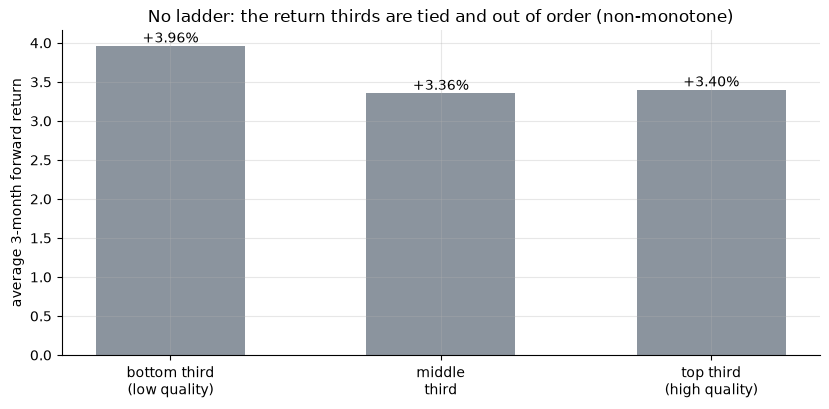

3-month forward return by quality third (low->high): ['+3.96%', '+3.36%', '+3.40%']


In [4]:
if HAVE_REAL:
    fr = st.event_drift_frame(PX, EV, horizon=63)
    mono = st.bucket_means(fr, 3)*100
else:
    mono = np.array(R['mono63'])
fig, ax = plt.subplots(figsize=(8.4, 4.2))
ax.bar(['bottom third\n(low quality)','middle\nthird','top third\n(high quality)'], mono,
       color=[GREY, GREY, GREY], width=.55)
for i,v in enumerate(mono): ax.annotate(f'{v:+.2f}%',(i,v),ha='center',va='bottom')
ax.set_ylabel('average 3-month forward return')
ax.set_title('No ladder: the return thirds are tied and out of order (non-monotone)')
plt.tight_layout(); plt.show()
print('3-month forward return by quality third (low->high):', [f'{v:+.2f}%' for v in mono])

No staircase — and the highest-quality third actually sits a touch *below* the lowest. The clean-quality names don't reliably out-return the noisy ones over the next quarter. Compare that to the *earnings* chart above, which is a clean, ordered separation. Same signal, two totally different answers: it grades the **business's earnings**, not the **stock**.

## 5 · The verdict

- **Does it flag earnings quality? — Confirmed.** High-quality earnings persist (+0.87 vs +0.27) and are ~5× less volatile (0.5% vs 2.4%). Real, mechanical, not in dispute.
- **Signal (returns) — None.** The return spread is a near-zero **-0.4%/yr**, faintly the *wrong* sign (robust *t* = -0.18), with a flat, out-of-order event drift. There is no evidence the market pays for accrual quality — here it slightly *penalises* it.
- **Tradability — Mirage.** You can't get paid for an edge that isn't there (and leans the wrong way). It fails before costs are even charged.

> The honest one-liner: *accrual quality tells you how flaky a firm's earnings are, and the market already knows.*

## 6 · Going further 🚪

- **The direction twist.** The academic *factor* version of this (Francis et al. 2005) argues poor accrual quality should earn a **higher** return — a premium for bearing information risk — the opposite of the retail "buy quality" pitch. Our faint wrong-signed tilt is consistent with that risk story, but it's far too weak to certify *either* direction.
- **The coverage caveat is real.** The rolling window needs ~4 years of clean quarterly cash-flow history before a first signal, and the cross-section grows from ≈26 names (2012) to ≈40 (2024+). A wider, deeper panel might sharpen the return test — though the flat event drift makes a hidden edge unlikely.
- **Sibling studies:** [231-sloan-accruals](../../231-sloan-accruals/) (the accrual *level*), [522-percent-operating-accruals](../../522-percent-operating-accruals/) (accruals scaled by earnings), [539-cash-flow-volatility](../../539-cash-flow-volatility/) (raw cash-flow vol), and [52-smoke-screen](../../52-smoke-screen/) (discretionary-accrual manipulation). See [docs/references.md](docs/references.md) for the exact dedup.

*Think the alpha is in the information-risk premium, not the quality discount? Build the factor, show a certifiable net spread on the size you'd actually run — then we'll talk.*